In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("world_data_full_apply_nulos.csv", index_col=0)
df.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe


1. Resumen básico de indicadores clave
Trabajaremos con estas variables numéricas:

population

density

life_expectancy

fertility_rate

gdp

Calcula, para cada una de estas variables:

Media

Mediana

Desviación estándar

Mínimo

Máximo

In [13]:
df[["population", "density", "life_expectancy", "fertility_rate", "gdp"]].describe().T

,count,mean,std,min,25%,50%,75%,max
population,39.0,3.335427e+02,2.964675e+02,1.008400e+01,8.713000e+01,2.150560e+02,5.561625e+02,9.735600e+02
density,195.0,1.345045e+02,1.573068e+02,1.265000e+00,2.616850e+01,8.300000e+01,1.655000e+02,8.470000e+02
life_expectancy,187.0,7.227968e+01,7.483661e+00,5.280000e+01,6.700000e+01,7.320000e+01,7.750000e+01,8.540000e+01
fertility_rate,188.0,2.698138e+00,1.282267e+00,9.800000e-01,1.705000e+00,2.245000e+00,3.597500e+00,6.910000e+00
gdp,193.0,4.772959e+11,2.172173e+12,4.727146e+07,8.454620e+09,3.438723e+10,2.340940e+11,2.142770e+13


In [19]:
# --- POPULATION ---
media_population = df["population"].mean()
mediana_population = df["population"].median()
desviacion_population = df["population"].std()
min_population = df["population"].min()
max_population = df["population"].max()

# --- DENSITY ---
media_density = df["density"].mean()
mediana_density = df["density"].median()
desviacion_density = df["density"].std()
min_density = df["density"].min()
max_density = df["density"].max()

# --- LIFE EXPECTANCY ---
media_life_expectancy = df["life_expectancy"].mean()
mediana_life_expectancy = df["life_expectancy"].median()
desviacion_life_expectancy = df["life_expectancy"].std()
min_life_expectancy = df["life_expectancy"].min()
max_life_expectancy = df["life_expectancy"].max()

# --- FERTILITY RATE ---
media_fertility_rate = df["fertility_rate"].mean()
mediana_fertility_rate = df["fertility_rate"].median()
desviacion_fertility_rate = df["fertility_rate"].std()
min_fertility_rate = df["fertility_rate"].min()
max_fertility_rate = df["fertility_rate"].max()

# --- GDP ---
media_gdp = df["gdp"].mean()
mediana_gdp = df["gdp"].median()
desviacion_gdp = df["gdp"].std()
min_gdp = df["gdp"].min()
max_gdp = df["gdp"].max()


Interpreta:

Elige dos variables y comenta si la media y la mediana están próximas o muy separadas.

¿Qué te sugiere esto sobre la posible presencia de valores extremos (outliers)?

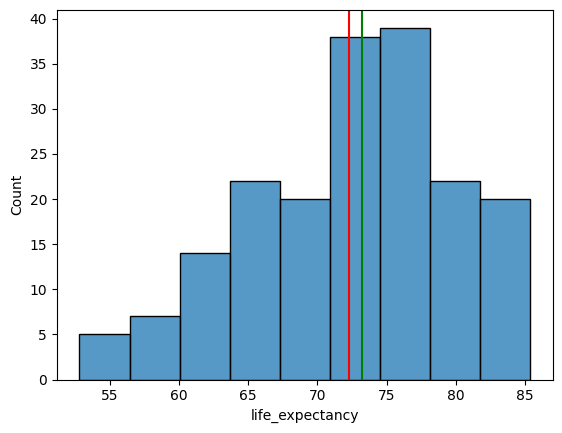

In [20]:
sns.histplot(data=df, x= "life_expectancy")
plt.axvline(media_life_expectancy, color= "red")
plt.axvline(mediana_life_expectancy, color= "green")

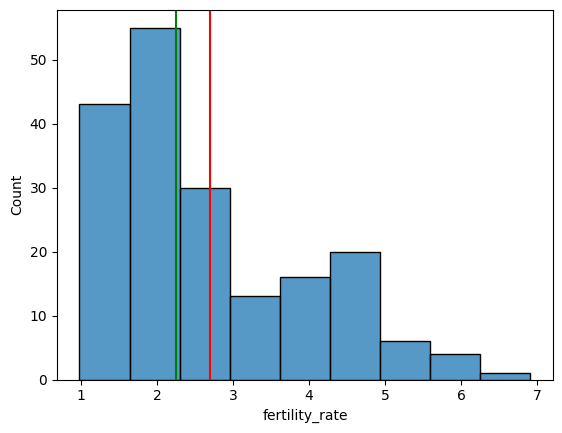

In [21]:
sns.histplot(data=df, x= "fertility_rate")
plt.axvline(media_fertility_rate, color= "red")
plt.axvline(mediana_fertility_rate, color= "green")

2. Distribución y forma: esperanza de vida vs. fertilidad
Variables:

life_expectancy

fertility_rate


Para cada variable:

Muestra un histograma.

Calcula la media y la mediana.

Interpreta:

¿La distribución parece aproximadamente simétrica, sesgada a la derecha o a la izquierda?

¿En cuál de las dos variables la media se ve más afectada por posibles valores extremos?

¿En cuál te parece más “robusto” el uso de la mediana?

3. Población total vs. densidad de población
Variables:

population

density


Calcula para ambas:

Media, mediana, desviación estándar.

Dibuja un histograma de population y otro de density.


Interpreta:

¿Cuál de las dos variables parece más concentrada (menos dispersa)?

¿Por qué no es lo mismo analizar population que density cuando comparamos países?

4. Comparando grupos con medias y medianas: países más y menos ricos

Variable base:

gdp


Calcula la mediana de gdp en el conjunto de datos.


Crea dos grupos de países:

grupo_bajo_gdp: países con gdp por debajo (o igual) de la mediana.

grupo_alto_gdp: países con gdp por encima de la mediana.


Para cada grupo, calcula la media y la mediana de:

life_expectancy

infant_mortality

Interpreta:

¿En qué grupo la esperanza de vida es mayor, de media?

¿En qué grupo la mortalidad infantil es más alta?

En lenguaje de políticas públicas, ¿qué conclusión preliminar podrías sacar de esta comparación simple?

5. Bonus: variabilidad de la fuerza laboral
Variable:

population_labor_force_participation


Calcula:

Media

Mediana

Desviación estándar

Percentiles 25, 50 y 75.


Interpreta:

¿Está la participación en la fuerza laboral muy concentrada alrededor de un valor, o es bastante dispersa?

¿Qué te indica la comparación entre los percentiles 25 y 75 sobre las diferencias entre países?